In [1]:
library(Seurat)
library(dplyr)
library(tidyr)
library(ggplot2)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [51]:
PATH_DATA <- "~/SysBioMed-PLAs/data/datasets/gated_our_dataset_processed.rds"
OUT_DIR <- "../../results/sample_qc/impact"

sample_col <- "donor_id"
celltype_col <- "lineage"
pla_col <- "pla_status"

positive_val <- "PLA"
negative_val <- "platelet-free"

max_ci_width <- 0.10
min_platelet_free <- 20

dir.create(OUT_DIR, recursive = TRUE, showWarnings = FALSE)

In [ ]:
dataset <- readRDS(PATH_DATA)

In [ ]:
meta <- dataset@meta.data
meta <- meta %>%
  mutate(
    cell_id = rownames(dataset@meta.data),
    sample_id = .data[[sample_col]],
    celltype_id = .data[[celltype_col]],
    pla_status_id = .data[[pla_col]]
  )

In [39]:
colnames(meta)

[1] "orig.ident"                              
 [2] "nCount_RNA"                              
 [3] "nFeature_RNA"                            
 [4] "nCount_ADT"                              
 [5] "nFeature_ADT"                            
 [6] "reference_genome"                        
 [7] "gene_annotation_version"                 
 [8] "alignment_software"                      
 [9] "intronic_reads_counted"                  
[10] "library_id"                              
[11] "assay_ontology_term_id"                  
[12] "sequenced_fragment"                      
[13] "institute"                               
[14] "library_id_repository"                   
[15] "is_primary_data"                         
[16] "cell_type_ontology_term_id"              
[17] "author_cell_type"                        
[18] "sample_preservation_method"              
[19] "development_stage_ontology_term_id"      
[20] "sample_collection_method"                
[21] "tissue_source"                           
[22] "donor_BMI_at_collection"                 
[23] "tissue_type"                             
[24] "suspension_enriched_cell_types"          
[25] "suspension_type"                         
[26] "donor_id"                                
[27] "donor_age"                               
[28] "self_reported_ethnicity_ontology_term_id"
[29] "donor_cause_of_death"                    
[30] "donor_living_at_sample_collection"       
[31] "donor_smoking_status"                    
[32] "disease_ontology_term_id"                
[33] "sex_ontology_term_id"                    
[34] "cmv"                                     
[35] "Gross_annotation"                        
[36] "tissue_ontology_term_id"                 
[37] "suspension_derivation_process"           
[38] "suspension_depletion_factors"            
[39] "suspension_depleted_cell_types"          
[40] "suspension_dissociation_reagent"         
[41] "suspension_dissociation_time"            
[42] "library_id_demultiplexed_tissue"         
[43] "cell_type"                               
[44] "assay"                                   
[45] "disease"                                 
[46] "sex"                                     
[47] "tissue"                                  
[48] "self_reported_ethnicity"                 
[49] "development_stage"                       
[50] "observation_joinid"                      
[51] "percent.mt"                              
[52] "percent.ribo"                            
[53] "percent.hb"                              
[54] "mt_outlier_all"                          
[55] "is_outlier_RNA"                          
[56] "is_outlier_protein"                      
[57] "is_outlier"                              
[58] "scDblFinder.class"                       
[59] "scDblFinder.score"                       
[60] "RNA_snn_res.0.8"                         
[61] "seurat_clusters"                         
[62] "RNA_snn_res.0.25"                        
[63] "RNA.weight"                              
[64] "ADT_corrected.weight"                    
[65] "wsnn_res.0.5"                            
[66] "wsnn_res.0.25"                           
[67] "celltype_full"                           
[68] "lineage"                                 
[69] "pla_status"                              
[70] "celltype"                                
[71] "cell_id"                                 
[72] "sample_id"                               
[73] "celltype_id"                             
[74] "pla_status_id"

In [40]:
wilson_ci <- function(x, n, conf_level = 0.95) {
  z <- qnorm(1 - (1 - conf_level) / 2)
  p <- x / n
  
  denom <- 1 + z^2 / n
  center <- (p + z^2 / (2 * n)) / denom
  half_width <- (z * sqrt((p * (1 - p) / n) + (z^2 / (4 * n^2)))) / denom
  
  lower <- pmax(0, center - half_width)
  upper <- pmin(1, center + half_width)
  
  data.frame(
    ci_lower = lower,
    ci_upper = upper,
    ci_width = upper - lower
  )
}

In [41]:
summary_table <- meta %>%
  filter(!is.na(pla_status_id)) %>%
  group_by(sample_id, celltype_id) %>%
  summarise(
    n_cells = n(),
    n_PLA = sum(pla_status_id == positive_val, na.rm = TRUE),
    n_platelet_free = sum(pla_status_id == negative_val, na.rm = TRUE),
    freq_PLA = n_PLA / n_cells,
    median_nCount_RNA = median(nCount_RNA, na.rm = TRUE),
    median_nCount_ADT = median(nCount_ADT, na.rm = TRUE),
    median_percent_mt = median(percent.mt, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(freq_PLA))

ci_df <- wilson_ci(
  x = summary_table$n_PLA,
  n = summary_table$n_cells
)

summary_table <- bind_cols(summary_table, ci_df)

neg_threshold <- summary_table %>%
  filter(n_platelet_free > 0) %>%
  summarise(threshold = quantile(n_platelet_free, probs = 0.10, na.rm = TRUE)) %>%
  pull(threshold)

neg_threshold <- as.numeric(max(neg_threshold, 20))

summary_table <- summary_table %>%
  mutate(
    enough_precision = ci_width <= max_ci_width,
    enough_negative_control = n_platelet_free >= neg_threshold,
    usable_celltype_sample = enough_precision & enough_negative_control
  ) %>%
  rowwise() %>%
  ungroup()

write.csv(
  summary_table,
  file.path(OUT_DIR, "01_sample_celltype_summary.csv"),
  row.names = FALSE
)


[1] "759B" "778C" "637C" "768B" "D564" "D520" "694B" "D512" "D570" "D534"
[11] "D529" "D543" "621B" "D528" "D523" "D496" "D533" "D503"

[1] 0.001174456 0.793450686

[1] 119

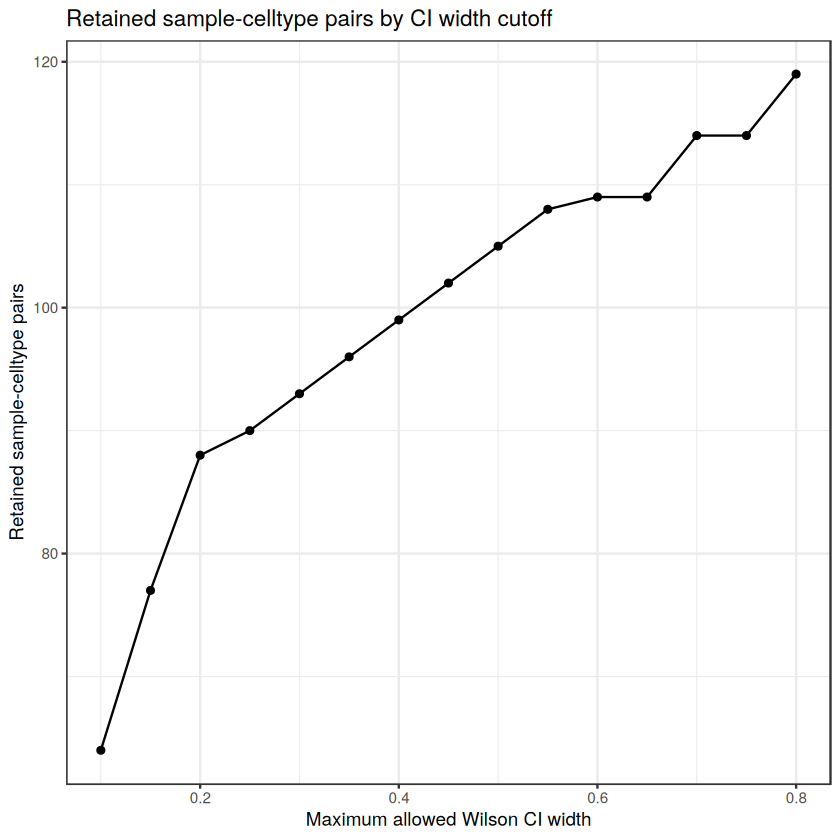

In [42]:
unique(summary_table$sample_id)
range(summary_table$ci_width, na.rm = TRUE)
nrow(summary_table)


ci_grid <- seq(0.1, 0.8, by = 0.05)

retention_df <- lapply(ci_grid, function(cutoff) {
  tmp <- summary_table %>%
    mutate(usable = ci_width <= cutoff)
  
  data.frame(
    max_ci_width = cutoff,
    retained_pairs = sum(tmp$usable, na.rm = TRUE),
    retained_cells = sum(tmp$n_cells[tmp$usable], na.rm = TRUE),
    retained_PLA = sum(tmp$n_PLA[tmp$usable], na.rm = TRUE)
  )
}) %>%
  bind_rows()

p_retention_current <- ggplot(retention_df, aes(x = max_ci_width, y = retained_pairs)) +
  geom_line() +
  geom_point() +
  theme_bw() +
  labs(
    title = "Retained sample-celltype pairs by CI width cutoff",
    x = "Maximum allowed Wilson CI width",
    y = "Retained sample-celltype pairs"
  )

print(p_retention_current)

In [43]:
usable_pairs <- summary_table %>%
  filter(usable_celltype_sample) %>%
  select(sample_id, celltype_id, n_cells, n_PLA, n_platelet_free, freq_PLA, ci_lower, ci_upper, ci_width, enough_negative_control)

excluded_pairs <- summary_table %>%
  filter(!usable_celltype_sample) %>%
  select(sample_id, celltype_id, n_cells, n_PLA, n_platelet_free, freq_PLA, ci_lower, ci_upper, ci_width, enough_negative_control)

write.csv(
  usable_pairs,
  file.path(OUT_DIR, "02_usable_sample_celltype_pairs.csv"),
  row.names = FALSE
)

write.csv(
  excluded_pairs,
  file.path(OUT_DIR, "03_excluded_sample_celltype_pairs.csv"),
  row.names = FALSE
)

In [44]:
summary_table <- summary_table %>%
  mutate(
    sample_id = as.character(sample_id),
    celltype_id = as.character(celltype_id)
  )

sample_order <- summary_table %>%
  group_by(sample_id) %>%
  summarise(total_PLA = sum(n_PLA, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(total_PLA)) %>%
  pull(sample_id)

celltype_order <- summary_table %>%
  group_by(celltype_id) %>%
  summarise(total_PLA = sum(n_PLA, na.rm = TRUE), .groups = "drop") %>%
  arrange(total_PLA) %>%
  pull(celltype_id)

plot_df <- summary_table %>%
  complete(
    sample_id = sample_order,
    celltype_id = celltype_order,
    fill = list(
      n_cells = NA_integer_,
      n_PLA = NA_integer_,
      n_platelet_free = NA_integer_,  
      freq_PLA = NA_real_,
      ci_width = NA_real_,
      enough_precision = FALSE,
      enough_negative_control = FALSE,
      usable_celltype_sample = FALSE
    )
  ) %>%
  mutate(
    sample_id = factor(sample_id, levels = sample_order),
    celltype_id = factor(celltype_id, levels = celltype_order),
    freq_PLA_plot = ifelse(usable_celltype_sample, freq_PLA, NA_real_),
    label_fraction = case_when(
      is.na(n_cells) ~ "NA",
      !enough_precision & !enough_negative_control ~ "unstable\nlow neg",
      !enough_precision ~ "unstable",
      !enough_negative_control ~ "low neg",
      usable_celltype_sample ~ paste0(round(freq_PLA * 100, 1), "%"),
      TRUE ~ ""
    )
  )

In [45]:
head(dataset)

,orig.ident,nCount_RNA,nFeature_RNA,nCount_ADT,nFeature_ADT,reference_genome,gene_annotation_version,alignment_software,intronic_reads_counted,library_id,⋯,seurat_clusters,RNA_snn_res.0.25,RNA.weight,ADT_corrected.weight,wsnn_res.0.5,wsnn_res.0.25,celltype_full,lineage,pla_status,celltype
,<fct>,<dbl>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<fct>,<fct>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<chr>,<chr>
TGCTACCAGATACACA-1_CZI-IA13003100-9,blood_only,3230,1263,232,88,GRCh38,v98,Cell Ranger count v6.0.0,no,95944224-93a9-43ca-8aef-172ac8585f48,⋯,1,10,1.000000e+00,3.061690e-38,1,1,non-T cell/ non NK cell,Unassigned,NA,Non-T / non-NK cells
TTGACTTGTCGCTTCT-1_CZINY-0651-2,blood_only,5076,1579,1596,120,GRCh38,v98,Cell Ranger count v6.0.0,no,efde5ad2-4d6e-4be0-9667-0ebd5c5f5629,⋯,1,0,6.191413e-01,3.808587e-01,1,1,platelet-free CD4 T cells,CD4 T cells,platelet-free,CD4 T cells
GCAGTTAAGGGCTTGA-1_CZINY-0167-5,blood_only,5388,1954,2780,120,GRCh38,v98,Cell Ranger count v6.0.0,no,12875ce9-3971-4f64-b05b-20c489f3d9a1,⋯,0,3,9.651894e-01,3.481057e-02,0,0,platelet-free intermediate mono,Monocytes,platelet-free,Intermediate monocytes
GCAGCCAAGAAGGTTT-1_CZI-IA13003095-4,blood_only,5190,1763,16437,127,GRCh38,v98,Cell Ranger count v6.0.0,no,8f715b10-5f14-498a-b5c8-c9020ed22c2c,⋯,8,8,3.003403e-23,1.000000e+00,10,8,NA,NA,NA,NA
GTACTTTAGAAGGGTA-1_CZINY-0524-3,blood_only,2305,1041,907,112,GRCh38,v98,Cell Ranger count v6.0.0,no,aac9751d-ea56-470f-9db9-da73e4e946c8,⋯,5,2,8.960521e-01,1.039479e-01,4,5,platelet-free CD8 T cells,CD8 T cells,platelet-free,CD8 T cells
CTTGGCTTCGCATGAT-1_CZINY-0413-12,blood_only,2353,964,725,99,GRCh38,v98,Cell Ranger count v6.0.0,no,a83b0c2e-3b21-47d9-a60f-34d61d378b42,⋯,3,2,8.724479e-01,1.275521e-01,3,3,platelet-free Early NK cells,NK cells,platelet-free,Early NK cells
TACTTACGTCGCATCG-1_CZINY-0104-7,blood_only,2484,1114,388,71,GRCh38,v98,Cell Ranger count v6.0.0,no,da8b94f2-870e-4266-b201-c57a3f6adc2c,⋯,9,22,2.271123e-10,1.000000e+00,13,9,non-T cell/ non NK cell,Unassigned,NA,Non-T / non-NK cells
TTCTACAAGGCACATG-1_CZINY-0657-8,blood_only,3034,1261,2533,120,GRCh38,v98,Cell Ranger count v6.0.0,no,cc2983bd-4995-4d73-a76e-2e093fc6a330,⋯,0,1,9.999397e-01,6.027528e-05,0,0,non-B cells,Unassigned,NA,Non-B
CAACCTCTCCGCATAA-1_CZINY-0590-5,blood_only,3093,1427,3385,125,GRCh38,v98,Cell Ranger count v6.0.0,no,b0be6a20-d974-498e-979a-114a14ab2890,⋯,0,1,6.615337e-01,3.384663e-01,0,0,non-B cells,Unassigned,NA,Non-B


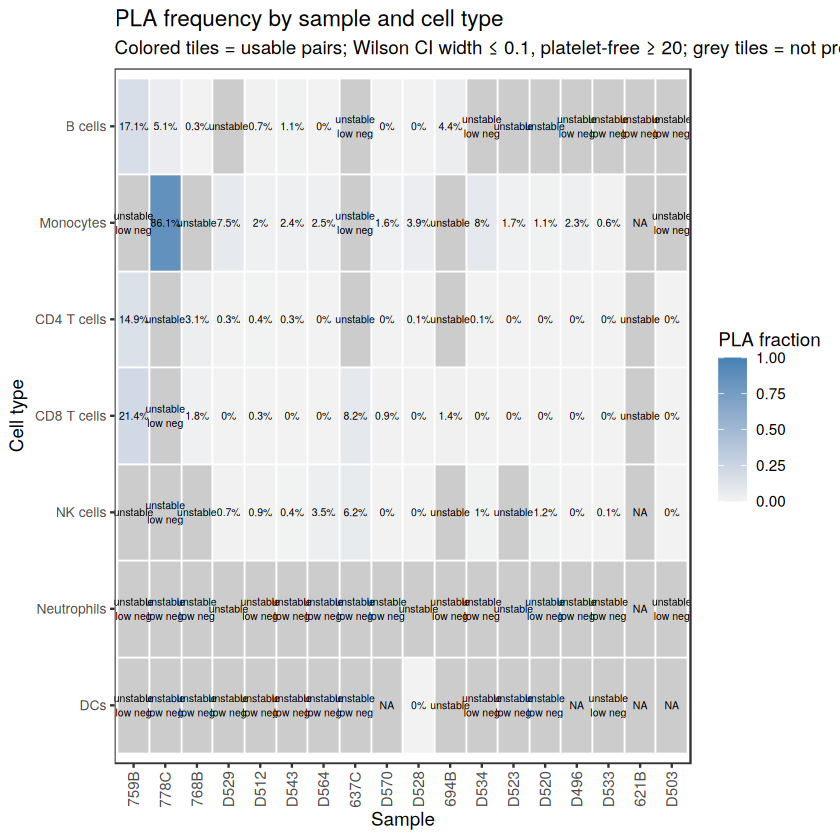

In [46]:
plot_width <- max(10, length(sample_order) * 0.35)
plot_height <- max(7, length(celltype_order) * 0.28)

p_heat <- ggplot(plot_df, aes(x = sample_id, y = celltype_id, fill = freq_PLA_plot)) +
  geom_tile(color = "white", linewidth = 0.35) +
  geom_text(aes(label = label_fraction), size = 2.1) +
  scale_fill_gradient(
    low = "grey95",
    high = "steelblue",
    limits = c(0, 1),
    na.value = "grey80"
  ) +
  theme_bw() +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    axis.text.y = element_text(size = 8)
  ) +
  labs(
    title = "PLA frequency by sample and cell type",
    subtitle = paste0(
      "Colored tiles = usable pairs; Wilson CI width ≤ ", max_ci_width,
      ", platelet-free ≥ ", neg_threshold,
      "; grey tiles = not present or not usable"
    ),
    x = "Sample",
    y = "Cell type",
    fill = "PLA fraction"
  )

print(p_heat)

ggsave(
  file.path(OUT_DIR, "04_PLA_frequency_by_sample_celltype_filtered.png"),
  p_heat,
  width = plot_width,
  height = plot_height,
  dpi = 300
)

In [47]:
qc_overview <- summary_table %>%
  summarise(
    total_pairs = n(),
    usable_pairs = sum(usable_celltype_sample, na.rm = TRUE),
    unstable_pairs = sum(!enough_precision, na.rm = TRUE),
    low_neg_pairs = sum(!enough_negative_control, na.rm = TRUE),
    retained_cells = sum(n_cells[usable_celltype_sample], na.rm = TRUE),
    retained_PLA = sum(n_PLA[usable_celltype_sample], na.rm = TRUE),
    total_cells = sum(n_cells, na.rm = TRUE),
    total_PLA = sum(n_PLA, na.rm = TRUE),
    retained_cell_fraction = retained_cells / total_cells,
    retained_PLA_fraction = retained_PLA / total_PLA
  )

print(qc_overview)
write.csv(qc_overview, file.path(OUT_DIR, "05_qc_filter_overview.csv"), row.names = FALSE)

# A tibble: 1 × 10
  total_pairs usable_pairs unstable_pairs low_neg_pairs retained_cells
        <int>        <int>          <int>         <int>          <int>
1         119           64             55            37          47536
# ℹ 5 more variables: retained_PLA <int>, total_cells <int>, total_PLA <int>,
#   retained_cell_fraction <dbl>, retained_PLA_fraction <dbl>


In [48]:
usable_by_celltype <- summary_table %>%
  group_by(celltype_id) %>%
  summarise(
    total_pairs = n(),
    usable_pairs = sum(usable_celltype_sample, na.rm = TRUE),
    usable_samples = n_distinct(sample_id[usable_celltype_sample]),
    retained_cells = sum(n_cells[usable_celltype_sample], na.rm = TRUE),
    retained_PLA = sum(n_PLA[usable_celltype_sample], na.rm = TRUE),
    mean_freq_PLA_usable = mean(freq_PLA[usable_celltype_sample], na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(retained_PLA))

print(usable_by_celltype, n = Inf)
write.csv(usable_by_celltype, file.path(OUT_DIR, "06_usable_by_celltype.csv"), row.names = FALSE)

# A tibble: 7 × 7
  celltype_id total_pairs usable_pairs usable_samples retained_cells
  <chr>             <int>        <int>          <int>          <int>
1 B cells              18            9              9           7244
2 Monocytes            17           12             12          11742
3 CD4 T cells          18           14             14          17868
4 CD8 T cells          18           16             16           6287
5 NK cells             17           12             12           4319
6 DCs                  14            1              1             76
7 Neutrophils          17            0              0              0
# ℹ 2 more variables: retained_PLA <int>, mean_freq_PLA_usable <dbl>


In [49]:
usable_by_sample <- summary_table %>%
  group_by(sample_id) %>%
  summarise(
    total_celltypes = n(),
    usable_celltypes = sum(usable_celltype_sample, na.rm = TRUE),
    retained_cells = sum(n_cells[usable_celltype_sample], na.rm = TRUE),
    retained_PLA = sum(n_PLA[usable_celltype_sample], na.rm = TRUE),
    mean_freq_PLA_usable = mean(freq_PLA[usable_celltype_sample], na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(retained_PLA))

print(usable_by_sample, n = Inf)
write.csv(usable_by_sample, file.path(OUT_DIR, "07_usable_by_sample.csv"), row.names = FALSE)

# A tibble: 18 × 6
   sample_id total_celltypes usable_celltypes retained_cells retained_PLA
   <chr>               <int>            <int>          <int>        <int>
 1 759B                    7                3           6318         1059
 2 778C                    7                2            640          201
 3 D529                    7                4           3244           79
 4 D512                    7                5           4579           55
 5 D543                    7                5           2998           54
 6 D564                    7                5           2165           41
 7 D570                    6                5           2973           36
 8 D528                    7                6           3893           34
 9 637C                    7                2            304           22
10 D534                    7                4           5383           17
11 768B                    7                3           2490           16
12 D523            

In [50]:
usable_pairs <- summary_table %>%
  filter(usable_celltype_sample) %>%
  select(sample_id, celltype_id)

meta_usable <- meta %>%
  semi_join(usable_pairs, by = c("sample_id", "celltype_id"))

usable_cells <- meta_usable$cell_id

dataset_usable <- subset(dataset, cells = usable_cells)

saveRDS(
  dataset_usable,
  file.path(OUT_DIR, "dataset_usable_sample_celltype_pairs.rds")
)

saveRDS(
  summary_table,
  file.path(OUT_DIR, "sample_celltype_frequency_QC_table.rds")
)